## Curstomer Abandoned Journeys 

An abandoned journey is defined as a journey that contains a `start` event but does not contain a `confirm` event.

The analysis focuses on understanding how frequently journeys are abandoned, at which stage customers leave the process, and whether abandonment differs between the Control and Test groups.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_web_data = pd.read_csv("df_clean_web_data.csv")

In [3]:
df_web_data.shape

(744641, 5)

In [4]:
df_web_data.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [5]:
df_web_data["date_time"] = pd.to_datetime(df_web_data["date_time"])

In [6]:
df_web_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 744641 entries, 0 to 744640
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   client_id     744641 non-null  int64         
 1   visitor_id    744641 non-null  str           
 2   visit_id      744641 non-null  str           
 3   process_step  744641 non-null  str           
 4   date_time     744641 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 28.4 MB


In [7]:
df_journey = df_web_data.sort_values(["client_id", "visit_id", "date_time"]).copy()

In [8]:
journeys = (df_journey.groupby(["client_id","visit_id"]).agg(date_time_start=("date_time","min"),
                                                            date_time_stop = ("date_time","max"),
                                                            steps = ("process_step",list),
                                                            n_events=("process_step","size")
                                                            ).reset_index())
journeys.head()

,client_id,visit_id,date_time_start,date_time_stop,steps,n_events
0,169,749567106_99161211863_557568,2017-04-12 20:19:36,2017-04-12 20:23:09,"[start, step_1, step_2, step_3, confirm]",5
1,336,649044751_80905125055_554468,2017-06-01 07:26:55,2017-06-01 07:42:43,"[start, start]",2
2,546,731811517_9330176838_94847,2017-06-17 10:03:29,2017-06-17 10:05:42,"[start, step_1, step_2, step_3, confirm]",5
3,555,637149525_38041617439_716659,2017-04-15 12:57:56,2017-04-15 13:00:34,"[start, step_1, step_2, step_3, confirm]",5
4,647,40369564_40101682850_311847,2017-04-12 15:41:28,2017-04-12 15:47:45,"[start, step_1, step_2, step_3, confirm]",5


In [9]:
# Abandoned journeys
abandoned_journeys = journeys[journeys["steps"].apply(lambda x: "start" in x and "confirm" not in x)].copy()
abandoned_journeys

,client_id,visit_id,date_time_start,date_time_stop,steps,n_events
1,336,649044751_80905125055_554468,2017-06-01 07:26:55,2017-06-01 07:42:43,"[start, start]",2
7,805,451173196_11661340552_563345,2017-06-15 19:09:13,2017-06-15 19:11:28,"[start, step_1, step_2, step_2, start]",5
8,805,72221519_52513154978_430287,2017-06-17 19:23:17,2017-06-17 19:23:20,"[start, step_1]",2
9,805,905546080_75813398358_250101,2017-06-08 01:10:29,2017-06-08 01:11:49,"[start, step_1]",2
11,934,7076463_57954418406_971348,2017-04-18 02:36:30,2017-04-18 02:38:52,"[start, start, start, start]",4
...,...,...,...,...,...,...
159103,9999529,580142688_50063971472_421281,2017-04-01 11:04:47,2017-04-01 11:05:28,"[start, step_1]",2
159104,9999626,182723364_27031318473_880901,2017-05-14 09:07:51,2017-05-14 09:07:59,"[start, step_1]",2
159105,9999729,493310979_9209676464_421146,2017-04-20 14:21:27,2017-04-20 14:28:57,"[start, step_1, step_2, start]",4
159107,9999729,99583652_41711450505_426179,2017-04-05 13:40:49,2017-04-05 13:41:04,"[start, step_1]",2


To understand where customers abandon the process, we identify the last process step recorded in each abandoned journey.

This allows us to determine at which stage customers leave the journey before reaching the confirmation step.

In [10]:
abandoned_journeys["last_step"] = abandoned_journeys["steps"].apply(lambda x: x[-1])
abandoned_journeys["last_step"].value_counts()

last_step
start     41734
step_1    12405
step_3     7863
step_2     5768
Name: count, dtype: int64

LAST RECORDED STEP

41.734 abandoned journeys have start as their last recorded event.

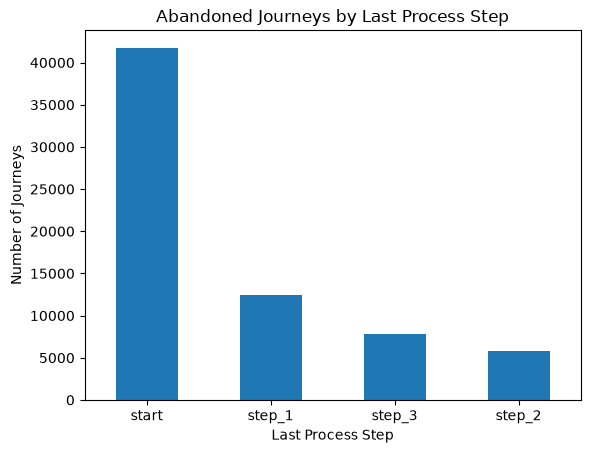

In [11]:
abandoned_journeys["last_step"].value_counts().plot(kind="bar")

plt.title("Abandoned Journeys by Last Process Step")
plt.xlabel("Last Process Step")
plt.ylabel("Number of Journeys")
plt.xticks(rotation=0)
plt.show()

In [12]:
step_order = {
    "start":0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}
abandoned_journeys["furthest_step"] = abandoned_journeys["steps"].apply(lambda x: max(x, key=lambda step: step_order[step]))

In [13]:
abandoned_journeys["furthest_step"].value_counts()

furthest_step
start     26924
step_1    15301
step_3    15240
step_2    10305
Name: count, dtype: int64

FURTHEST STEP REACHED

A substantial number of abandoned journeys reached step_3 without reaching confirmation.

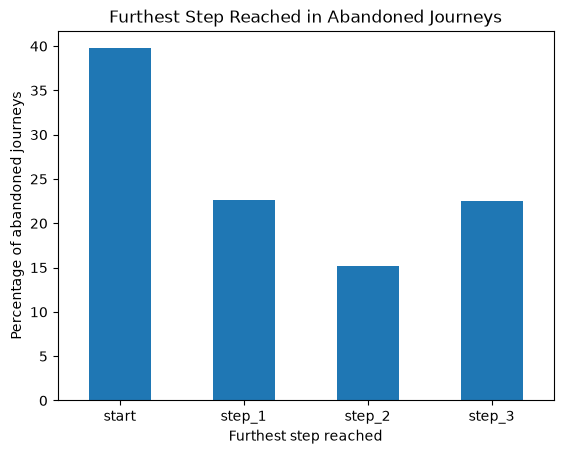

In [14]:
abandoned_journeys["furthest_step"].value_counts(
    normalize=True
).mul(100).reindex(
    ["start", "step_1", "step_2", "step_3"]
).plot(kind="bar")

plt.title("Furthest Step Reached in Abandoned Journeys")
plt.xlabel("Furthest step reached")
plt.ylabel("Percentage of abandoned journeys")
plt.xticks(rotation=0)
plt.show()

#### Abandonment by experimental group

To assess whether the experimental groups experienced different levels of abandonment, we compare the Control and Test groups.

In [15]:
url = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_experiment_clients.txt"
df_final_experiment_clients = pd.read_csv(url, sep=",")
df_final_experiment_clients.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [16]:
df_final_experiment_clients["Variation"].value_counts(dropna=False)

Variation
Test       26968
Control    23532
NaN        20109
Name: count, dtype: int64

In [17]:
experiment_journeys = journeys.merge(
    df_final_experiment_clients,
    on="client_id",
    how="inner"
)

In [18]:
abandoned_experiment = abandoned_journeys.merge(
    df_final_experiment_clients,
    on="client_id",
    how="left"
)
abandoned_experiment = abandoned_experiment[
    abandoned_experiment["Variation"].isin(["Control", "Test"])
].copy()

In [19]:
abandoned_experiment

,client_id,visit_id,date_time_start,date_time_stop,steps,n_events,last_step,furthest_step,Variation
4,934,7076463_57954418406_971348,2017-04-18 02:36:30,2017-04-18 02:38:52,"[start, start, start, start]",4,start,start,Test
5,1028,557292053_87239438319_391157,2017-04-08 18:51:28,2017-04-08 19:00:26,"[start, step_1, step_1, step_2, step_3, step_1...",9,step_1,step_3,Control
6,1104,543158812_46395476577_767725,2017-06-12 07:49:18,2017-06-12 07:49:18,[start],1,start,start,Control
7,1104,643221571_99977972121_69283,2017-06-20 22:31:33,2017-06-20 22:31:33,[start],1,start,start,Control
8,1186,507052512_11309370126_442139,2017-04-08 15:59:16,2017-04-08 15:59:16,[start],1,start,start,Control
...,...,...,...,...,...,...,...,...,...
67764,9999150,982803842_91891255980_123078,2017-05-29 16:55:12,2017-05-29 16:55:30,"[start, step_1, start]",3,start,step_1,Test
67766,9999626,182723364_27031318473_880901,2017-05-14 09:07:51,2017-05-14 09:07:59,"[start, step_1]",2,step_1,step_1,Test
67767,9999729,493310979_9209676464_421146,2017-04-20 14:21:27,2017-04-20 14:28:57,"[start, step_1, step_2, start]",4,start,step_2,Test
67768,9999729,99583652_41711450505_426179,2017-04-05 13:40:49,2017-04-05 13:41:04,"[start, step_1]",2,step_1,step_1,Test


### KPI

#### Abandonment Rate

In [20]:
abandonment_summary = pd.DataFrame({
    "Total journeys": experiment_journeys.groupby("Variation").size(),
    "Abandoned journeys": abandoned_experiment.groupby("Variation").size()
})

abandonment_summary["Abandonment rate (%)"] = (
    abandonment_summary["Abandoned journeys"]
    / abandonment_summary["Total journeys"]
    * 100
)

abandonment_summary

,Total journeys,Abandoned journeys,Abandonment rate (%)
Variation,,,
Control,32243,16020,49.685203
Test,37204,15258,41.011719


The Test group shows a lower observed abandonment rate than the Control group. However, this descriptive difference alone does not establish whether the difference is statistically significant.

In [21]:
abandonment_rate = (
    len(abandoned_experiment) / len(experiment_journeys) * 100
)
abandonment_rate

32.16709860545477

#### Time before abandonment

In [22]:
abandoned_experiment["abandonment_duration"] = (
    abandoned_experiment["date_time_stop"]
    - abandoned_experiment["date_time_start"]
).dt.total_seconds() / 60

In [23]:
abandoned_experiment["abandonment_duration"].describe()

count    31278.000000
mean         3.514398
std          9.924738
min          0.000000
25%          0.000000
50%          0.900000
75%          3.466667
max        699.416667
Name: abandonment_duration, dtype: float64

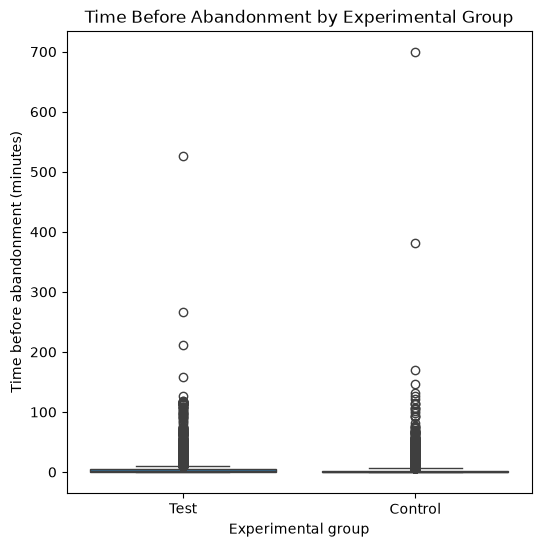

In [24]:
import seaborn as sns

plt.figure(figsize=(6, 6))

sns.boxplot(
    data=abandoned_experiment,
    x="Variation",
    y="abandonment_duration"
)

plt.xlabel("Experimental group")
plt.ylabel("Time before abandonment (minutes)")
plt.title("Time Before Abandonment by Experimental Group")
plt.show()

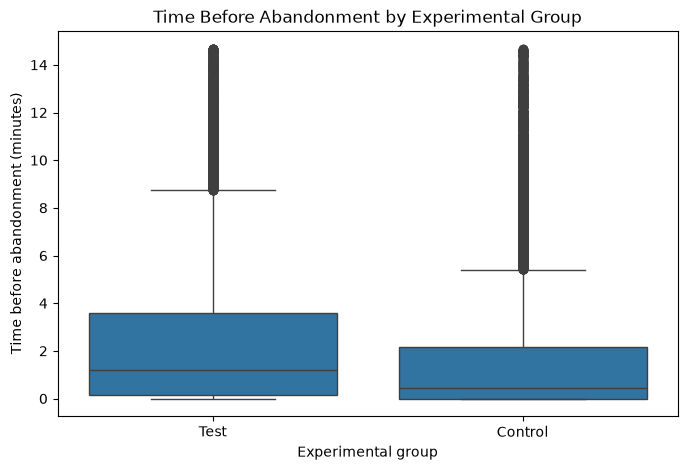

In [25]:
# dropping outliers

p95 = abandoned_experiment["abandonment_duration"].quantile(0.95)

plot_data = abandoned_experiment[
    abandoned_experiment["abandonment_duration"] <= p95
]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=plot_data,
    x="Variation",
    y="abandonment_duration"
)

plt.xlabel("Experimental group")
plt.ylabel("Time before abandonment (minutes)")
plt.title("Time Before Abandonment by Experimental Group")
plt.show()

In [26]:
time_summary = (
    abandoned_experiment
    .groupby("Variation")["abandonment_duration"]
    .agg(
        Mean="mean",
        Median="median"
    )
    .round(2)
)

time_summary

,Mean,Median
Variation,,
Control,2.84,0.52
Test,4.22,1.43


We also examine how long customers spend in the journey before abandoning it. The time is calculated as the difference between the first and last recorded event of each abandoned journey.

The Test group shows a higher time before abandonment than the Control group, both in terms of mean and median. The median abandonment time is 1.43 minutes for the Test group compared with 0.52 minutes for the Control group.

### Correlations 

In [27]:
url2 = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_demo.txt"
df_final_demo = pd.read_csv(url2, sep=",")
df_final_demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [28]:
df_final_demo.columns

Index(['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr',
       'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth'],
      dtype='str')

In [29]:
abandoned_journeys.columns

Index(['client_id', 'visit_id', 'date_time_start', 'date_time_stop', 'steps',
       'n_events', 'last_step', 'furthest_step'],
      dtype='str')

In [30]:
df_final_experiment_clients.columns

Index(['client_id', 'Variation'], dtype='str')

In [31]:
experiment_journeys["abandoned"] = (
    ~experiment_journeys["visit_id"].isin(
        abandoned_experiment["visit_id"]
    )
).astype(int)

In [ ]:
journeys_demo = experiment_journeys.merge(
    df_final_demo[
        [
            "client_id",
            "clnt_age",
            "clnt_tenure_mnth",
            "calls_6_mnth",
            "logons_6_mnth"
        ]
    ],
    on="client_id",
    how="left"
)

In [ ]:
corr = journeys_demo[
    [
        "abandoned",
        "clnt_age",
        "clnt_tenure_mnth",
        "calls_6_mnth",
        "logons_6_mnth"
    ]
].corr()
corr

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation with Journey Abandonment")
plt.show()